In [8]:
import dagshub
dagshub.init(repo_owner='MohammedTawfikEldeeb', repo_name='telcom-churn', mlflow=True)

Initialized MLflow to track repo "MohammedTawfikEldeeb/telcom-churn"

Repository MohammedTawfikEldeeb/telcom-churn initialized!

In [9]:
import mlflow

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
# split the dataset
from sklearn.model_selection import train_test_split


# preprossing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , LabelEncoder , OrdinalEncoder
from sklearn.pipeline import Pipeline , FeatureUnion
from sklearn_features.transformers import DataFrameSelector
from datasist.structdata import detect_outliers
from sklearn.model_selection import cross_val_score, cross_val_predict
from imblearn.over_sampling import SMOTE ,RandomOverSampler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report , confusion_matrix

In [11]:
df = pd.read_csv('data/data_processed.csv')
df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,customer_service_calls,churn,total_charge,total_minutes,total_calls
0,128,0,1,25,1,False,75.56,717.2,303
1,107,0,1,26,1,False,59.24,625.2,332
2,137,0,0,0,0,False,62.29,539.4,333
3,84,1,0,0,2,False,66.80,564.8,255
4,75,1,0,0,3,False,52.09,512.0,359


In [12]:
outlieres_indicies = detect_outliers(df ,0, df.select_dtypes(include = ['float64' ,'int64']))
100*(len(outlieres_indicies)/df.shape[0])

18.6018601860186

In [13]:
df.drop(outlieres_indicies , inplace = True)

🏃 View run RandomForest_with_removing_outlier at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/4c9b7bf505df43f185a5ed50198a55e3
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
Accuracy: 0.9758 | Precision: 0.9811 | Recall: 0.7027 | F1: 0.8189


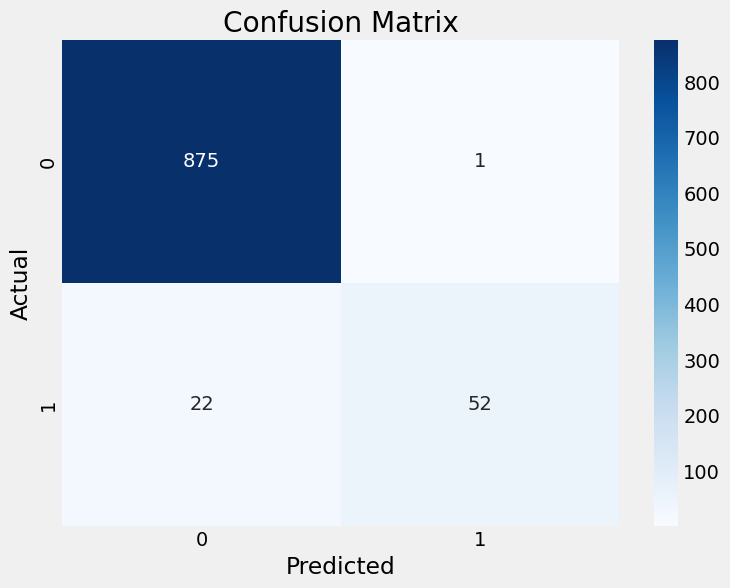

In [14]:
x = df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.35, random_state=42, stratify=y, shuffle=True
)

# ----------- Scale features -----------
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# ----------- RandomOverSampler on train only -----------
sampler = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = sampler.fit_resample(x_train_scaled, y_train)

# ----------- MLflow Run -----------
with mlflow.start_run():
    mlflow.set_tag("mlflow.runName", "RandomForest_with_removing_outlier")
    mlflow.set_tag("experiment_type", "handling outlier")
    mlflow.set_tag("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 15)

    # ----------- Model -----------
    model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
    model.fit(x_train_resampled, y_train_resampled)
    y_pred = model.predict(x_test_scaled)

    # ----------- Metrics -----------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    # ----------- Classification Report -----------
    classification_rep = classification_report(y_test, y_pred, output_dict=True)
    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # ----------- Confusion Matrix -----------
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # ----------- Dataset Snapshot -----------
    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("dataset.csv")

print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")